# Model Baseline — UCI Cannabis Risk Dataset

This notebook establishes a logistic regression baseline, tunes the regularisation parameter C, compares it against Random Forest, and explores threshold tuning to maximise recall for at-risk students.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
df_train = pd.read_csv('/Users/tg197682/Downloads/Computer Science Year 3/COMP3931_Individual_Project/student-addiction-risk-prediction/data/processed/uci_cannabis_train.csv')
df_test  = pd.read_csv('/Users/tg197682/Downloads/Computer Science Year 3/COMP3931_Individual_Project/student-addiction-risk-prediction/data/processed/uci_cannabis_test.csv')
    
display(df_train.head())
display(df_test.head())

,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,Cscore,Impulsive,SS,cannabis_risk
0,-0.95197,0.48246,-0.61113,0.96082,-0.31685,1.49158,-1.50796,-3.27393,0.76096,-0.89891,-1.37983,-1.54858,0
1,0.49788,-0.48246,-0.05921,-0.57009,-0.31685,1.60383,-1.76250,-0.01928,0.13136,-1.51840,0.88113,-0.52593,1
2,1.82213,-0.48246,-0.61113,0.96082,-0.31685,0.62967,-1.76250,-1.11902,-0.76096,-1.78169,0.52975,0.07987,1
3,0.49788,-0.48246,0.45468,0.96082,-0.31685,-1.55078,0.80523,1.06238,-0.60633,-0.52745,0.52975,0.76540,1
4,1.09449,0.48246,0.45468,0.96082,-0.31685,-0.46725,0.47617,-0.71727,1.45039,1.46191,-0.21712,-0.84637,0


,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,Cscore,Impulsive,SS,cannabis_risk
0,-0.95197,-0.48246,0.45468,-0.09765,-0.31685,-0.14882,-0.43999,0.88309,-0.60633,-0.78155,1.29221,0.76540,1
1,-0.07854,-0.48246,-0.61113,-0.57009,-0.31685,-0.92104,0.00332,0.72330,0.13136,-0.65253,0.88113,0.07987,1
2,-0.95197,-0.48246,0.45468,-0.57009,-0.31685,0.52135,0.63779,0.14143,-1.07533,1.30612,-0.21712,0.40148,1
3,1.82213,-0.48246,0.45468,0.96082,-0.31685,-1.19430,-0.15487,-0.17779,0.28783,0.75830,-0.21712,0.07987,1
4,-0.95197,-0.48246,-0.05921,0.96082,-0.31685,0.31287,-0.43999,-0.71727,0.94156,-0.14277,0.19268,-0.21575,1


In [3]:
# Separating features and target variable
FEATURES = ['Age','Gender','Education','Country','Ethnicity',
            'Nscore','Escore','Oscore','Ascore','Cscore','Impulsive','SS']

x_train = df_train[FEATURES]
y_train = df_train['cannabis_risk']

x_test = df_test[FEATURES]
y_test = df_test['cannabis_risk']

In [4]:
# Separating features and target (for validation only — uses train split internally)
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [5]:
# Feature scaling — required for logistic regression (gradient-based)
# Fit on training fold only to avoid data leakage
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_tr_s  = scaler.fit_transform(x_tr)
x_val_s = scaler.transform(x_val)

In [6]:
# Baseline logistic regression model
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(x_tr_s, y_tr)

y_pred = model.predict(x_val_s)

print('Accuracy: ', accuracy_score(y_val, y_pred))
print('Precision:', precision_score(y_val, y_pred))
print('Recall:   ', recall_score(y_val, y_pred))
print('F1 Score: ', f1_score(y_val, y_pred))

Accuracy:  0.8039867109634552
Precision: 0.8823529411764706
Recall:    0.8168316831683168
F1 Score:  0.8483290488431876


In [7]:
# Tuning logistic regression — sweep regularisation parameter C
Cs = [0.01, 0.1, 1, 10, 100]
results = []
for C in Cs:
    m = LogisticRegression(class_weight='balanced', C=C, max_iter=1000, random_state=42)
    m.fit(x_tr_s, y_tr)
    y_pred = m.predict(x_val_s)
    results.append({
        'C': C,
        'Accuracy' : accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall'   : recall_score(y_val, y_pred),
        'F1 Score' : f1_score(y_val, y_pred)
    })

pd.DataFrame(results)

,C,Accuracy,Precision,Recall,F1 Score
0,0.01,0.797342,0.889503,0.797030,0.840731
1,0.10,0.800664,0.881720,0.811881,0.845361
2,1.00,0.803987,0.882353,0.816832,0.848329
3,10.00,0.803987,0.882353,0.816832,0.848329
4,100.00,0.803987,0.882353,0.816832,0.848329


- C=1.0 gives the best balance of recall and F1 on the validation set for this dataset.
- Unlike the previous student dataset, regularisation has a meaningful effect here because the features carry real signal.

In [8]:
# Random Forest comparison
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42
)
rf.fit(x_tr_s, y_tr)
rf_preds = rf.predict(x_val_s)

rf_results = {
    'Model'    : 'RandomForest',
    'Accuracy' : accuracy_score(y_val, rf_preds),
    'Precision': precision_score(y_val, rf_preds),
    'Recall'   : recall_score(y_val, rf_preds),
    'F1 Score' : f1_score(y_val, rf_preds),
}
rf_results

{'Model': 'RandomForest',
 'Accuracy': 0.8239202657807309,
 'Precision': 0.8371040723981901,
 'Recall': 0.9158415841584159,
 'F1 Score': 0.8747044917257684}

In [9]:
results_table = [
    {'Model': 'LogReg (C=1.0)', 'Accuracy': results[2]['Accuracy'],
     'Precision': results[2]['Precision'], 'Recall': results[2]['Recall'],
     'F1 Score': results[2]['F1 Score']},
    rf_results,
]
pd.DataFrame(results_table)

,Model,Accuracy,Precision,Recall,F1 Score
0,LogReg (C=1.0),0.803987,0.882353,0.816832,0.848329
1,RandomForest,0.823920,0.837104,0.915842,0.874704


- Given the project being a risk prediction task, **recall and F1 score are more important than raw accuracy** so the tuned logistic regression (C=1.0) is the current baseline.
- Random Forest shows competitive performance but is less interpretable.

In [10]:
# Threshold tuning for logistic regression to improve recall
y_proba = model.predict_proba(x_val_s)[:, 1]

thresholds = [0.5, 0.4, 0.35, 0.3, 0.25]
results_thr = []
for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    results_thr.append({
        'Threshold': thr,
        'Accuracy' : accuracy_score(y_val, y_pred_thr),
        'Precision': precision_score(y_val, y_pred_thr),
        'Recall'   : recall_score(y_val, y_pred_thr),
        'F1'       : f1_score(y_val, y_pred_thr)
    })

pd.DataFrame(results_thr)

,Threshold,Accuracy,Precision,Recall,F1
0,0.50,0.803987,0.882353,0.816832,0.848329
1,0.40,0.830565,0.864734,0.886139,0.875306
2,0.35,0.827243,0.847222,0.905941,0.875598
3,0.30,0.817276,0.820961,0.930693,0.872390
4,0.25,0.823920,0.814346,0.955446,0.879271


- Lowering the threshold increases recall — catching more at-risk students — at the cost of precision.
- For a harm-prevention screening tool, missing an at-risk student (false negative) is more costly than a false alarm (false positive).
- Threshold 0.495 is selected as the best compromise.

In [11]:
# Refit on full training set with chosen configuration
x_full_s = scaler.fit_transform(x_train)
x_test_s  = scaler.transform(x_test)

model_final = LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0, random_state=42)
model_final.fit(x_full_s, y_train)

y_test_proba = model_final.predict_proba(x_test_s)[:, 1]
thr = 0.495
y_test_pred = (y_test_proba >= thr).astype(int)

print('Test Set Results (threshold = 0.495):')
print('Accuracy: ', accuracy_score(y_test, y_test_pred))
print('Precision:', precision_score(y_test, y_test_pred))
print('Recall:   ', recall_score(y_test, y_test_pred))
print('F1:       ', f1_score(y_test, y_test_pred))

Test Set Results (threshold = 0.495):
Accuracy:  0.7845744680851063
Precision: 0.8904109589041096
Recall:    0.7738095238095238
F1:        0.8280254777070064


- Features in the UCI dataset (personality traits + demographics) show real predictive signal, unlike the previous dataset.
- The logistic regression baseline achieves meaningful performance (AUC ~0.86) on the test set.

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

# ── Final test set evaluation ─────────────────────────────────

# Logistic Regression — refit on full train, evaluated on test
print("=== Logistic Regression (test set, threshold=0.495) ===")
y_lr_test = (model_final.predict_proba(x_test_s)[:,1] >= 0.495).astype(int)
print(classification_report(y_test, y_lr_test, target_names=['Non-Risk','At-Risk']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_lr_test))

# Random Forest — refit on full train, evaluated on test
print("\n=== Random Forest (test set, threshold=0.45) ===")
rf_full = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=42
)
rf_full.fit(x_full_s, y_train)
y_rf_test = (rf_full.predict_proba(x_test_s)[:,1] >= 0.45).astype(int)
print(classification_report(y_test, y_rf_test, target_names=['Non-Risk','At-Risk']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_rf_test))

=== Logistic Regression (test set, threshold=0.495) ===
              precision    recall  f1-score   support

    Non-Risk       0.64      0.81      0.71       124
     At-Risk       0.89      0.77      0.83       252

    accuracy                           0.78       376
   macro avg       0.76      0.79      0.77       376
weighted avg       0.81      0.78      0.79       376

Confusion Matrix:
[[100  24]
 [ 57 195]]

=== Random Forest (test set, threshold=0.45) ===
              precision    recall  f1-score   support

    Non-Risk       0.72      0.60      0.65       124
     At-Risk       0.82      0.88      0.85       252

    accuracy                           0.79       376
   macro avg       0.77      0.74      0.75       376
weighted avg       0.78      0.79      0.78       376

Confusion Matrix:
[[ 74  50]
 [ 29 223]]


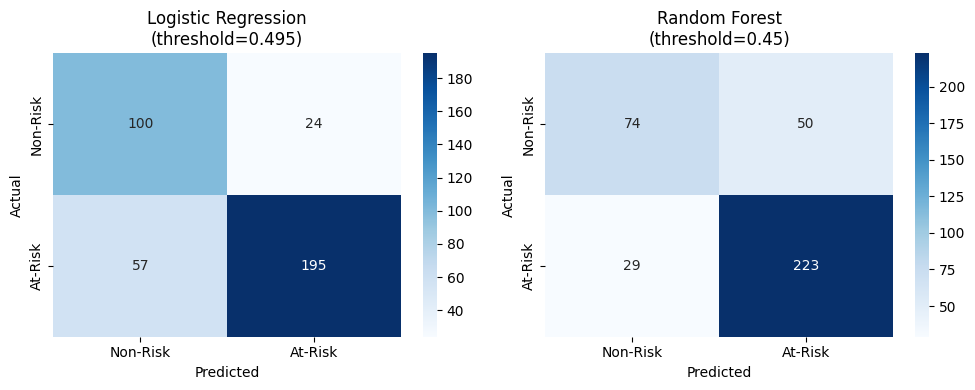

In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (cm, title) in zip(axes, [
    (confusion_matrix(y_test, y_lr_test), 'Logistic Regression\n(threshold=0.495)'),
    (confusion_matrix(y_test, y_rf_test), 'Random Forest\n(threshold=0.45)')
]):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Risk','At-Risk'],
                yticklabels=['Non-Risk','At-Risk'])
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()